In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

from sklearn.decomposition import PCA

In [4]:
import os
print(os.getcwd())
print(os.listdir())

C:\Users\User\Anaconda JJ\CLUSTERINGG
['.ipynb_checkpoints', 'BankChurners.csv', 'Bankcun.ipynb']


In [5]:
df = pd.read_csv('BankChurners.csv')

print("Jumlah Data dan Kolom:")
print(df.shape)

print("\n5 Data Pertama:")
print(df.head())

Jumlah Data dan Kolom:
(10127, 23)

5 Data Pertama:
   CLIENTNUM     Attrition_Flag  Customer_Age Gender  Dependent_count  \
0  768805383  Existing Customer            45      M                3   
1  818770008  Existing Customer            49      F                5   
2  713982108  Existing Customer            51      M                3   
3  769911858  Existing Customer            40      F                4   
4  709106358  Existing Customer            40      M                3   

  Education_Level Marital_Status Income_Category Card_Category  \
0     High School        Married     $60K - $80K          Blue   
1        Graduate         Single  Less than $40K          Blue   
2        Graduate        Married    $80K - $120K          Blue   
3     High School        Unknown  Less than $40K          Blue   
4      Uneducated        Married     $60K - $80K          Blue   

   Months_on_book  ...  Credit_Limit  Total_Revolving_Bal  Avg_Open_To_Buy  \
0              39  ...       12691

In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

In [7]:
print(df.describe())

          CLIENTNUM  Customer_Age  Dependent_count  Months_on_book  \
count  1.012700e+04  10127.000000     10127.000000    10127.000000   
mean   7.391776e+08     46.325960         2.346203       35.928409   
std    3.690378e+07      8.016814         1.298908        7.986416   
min    7.080821e+08     26.000000         0.000000       13.000000   
25%    7.130368e+08     41.000000         1.000000       31.000000   
50%    7.179264e+08     46.000000         2.000000       36.000000   
75%    7.731435e+08     52.000000         3.000000       40.000000   
max    8.283431e+08     73.000000         5.000000       56.000000   

       Total_Relationship_Count  Months_Inactive_12_mon  \
count              10127.000000            10127.000000   
mean                   3.812580                2.341167   
std                    1.554408                1.010622   
min                    1.000000                0.000000   
25%                    3.000000                2.000000   
50%            

In [8]:
print(df.isnull().sum())

CLIENTNUM                                                                                                                             0
Attrition_Flag                                                                                                                        0
Customer_Age                                                                                                                          0
Gender                                                                                                                                0
Dependent_count                                                                                                                       0
Education_Level                                                                                                                       0
Marital_Status                                                                                                                        0
Income_Category                                 

In [9]:
df_cluster = df.drop([
    'CLIENTNUM',
    'Attrition_Flag'
], axis=1)

In [10]:
le = LabelEncoder()

for col in df_cluster.select_dtypes(include='object').columns:
    df_cluster[col] = le.fit_transform(df_cluster[col])

print(df_cluster.head())

   Customer_Age  Gender  Dependent_count  Education_Level  Marital_Status  \
0            45       1                3                3               1   
1            49       0                5                2               2   
2            51       1                3                2               1   
3            40       0                4                3               3   
4            40       1                3                5               1   

   Income_Category  Card_Category  Months_on_book  Total_Relationship_Count  \
0                2              0              39                         5   
1                4              0              44                         6   
2                3              0              36                         4   
3                4              0              34                         3   
4                2              0              21                         5   

   Months_Inactive_12_mon  ...  Credit_Limit  Total_Revolving_

In [11]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_cluster)

print(X_scaled.shape)

(10127, 21)


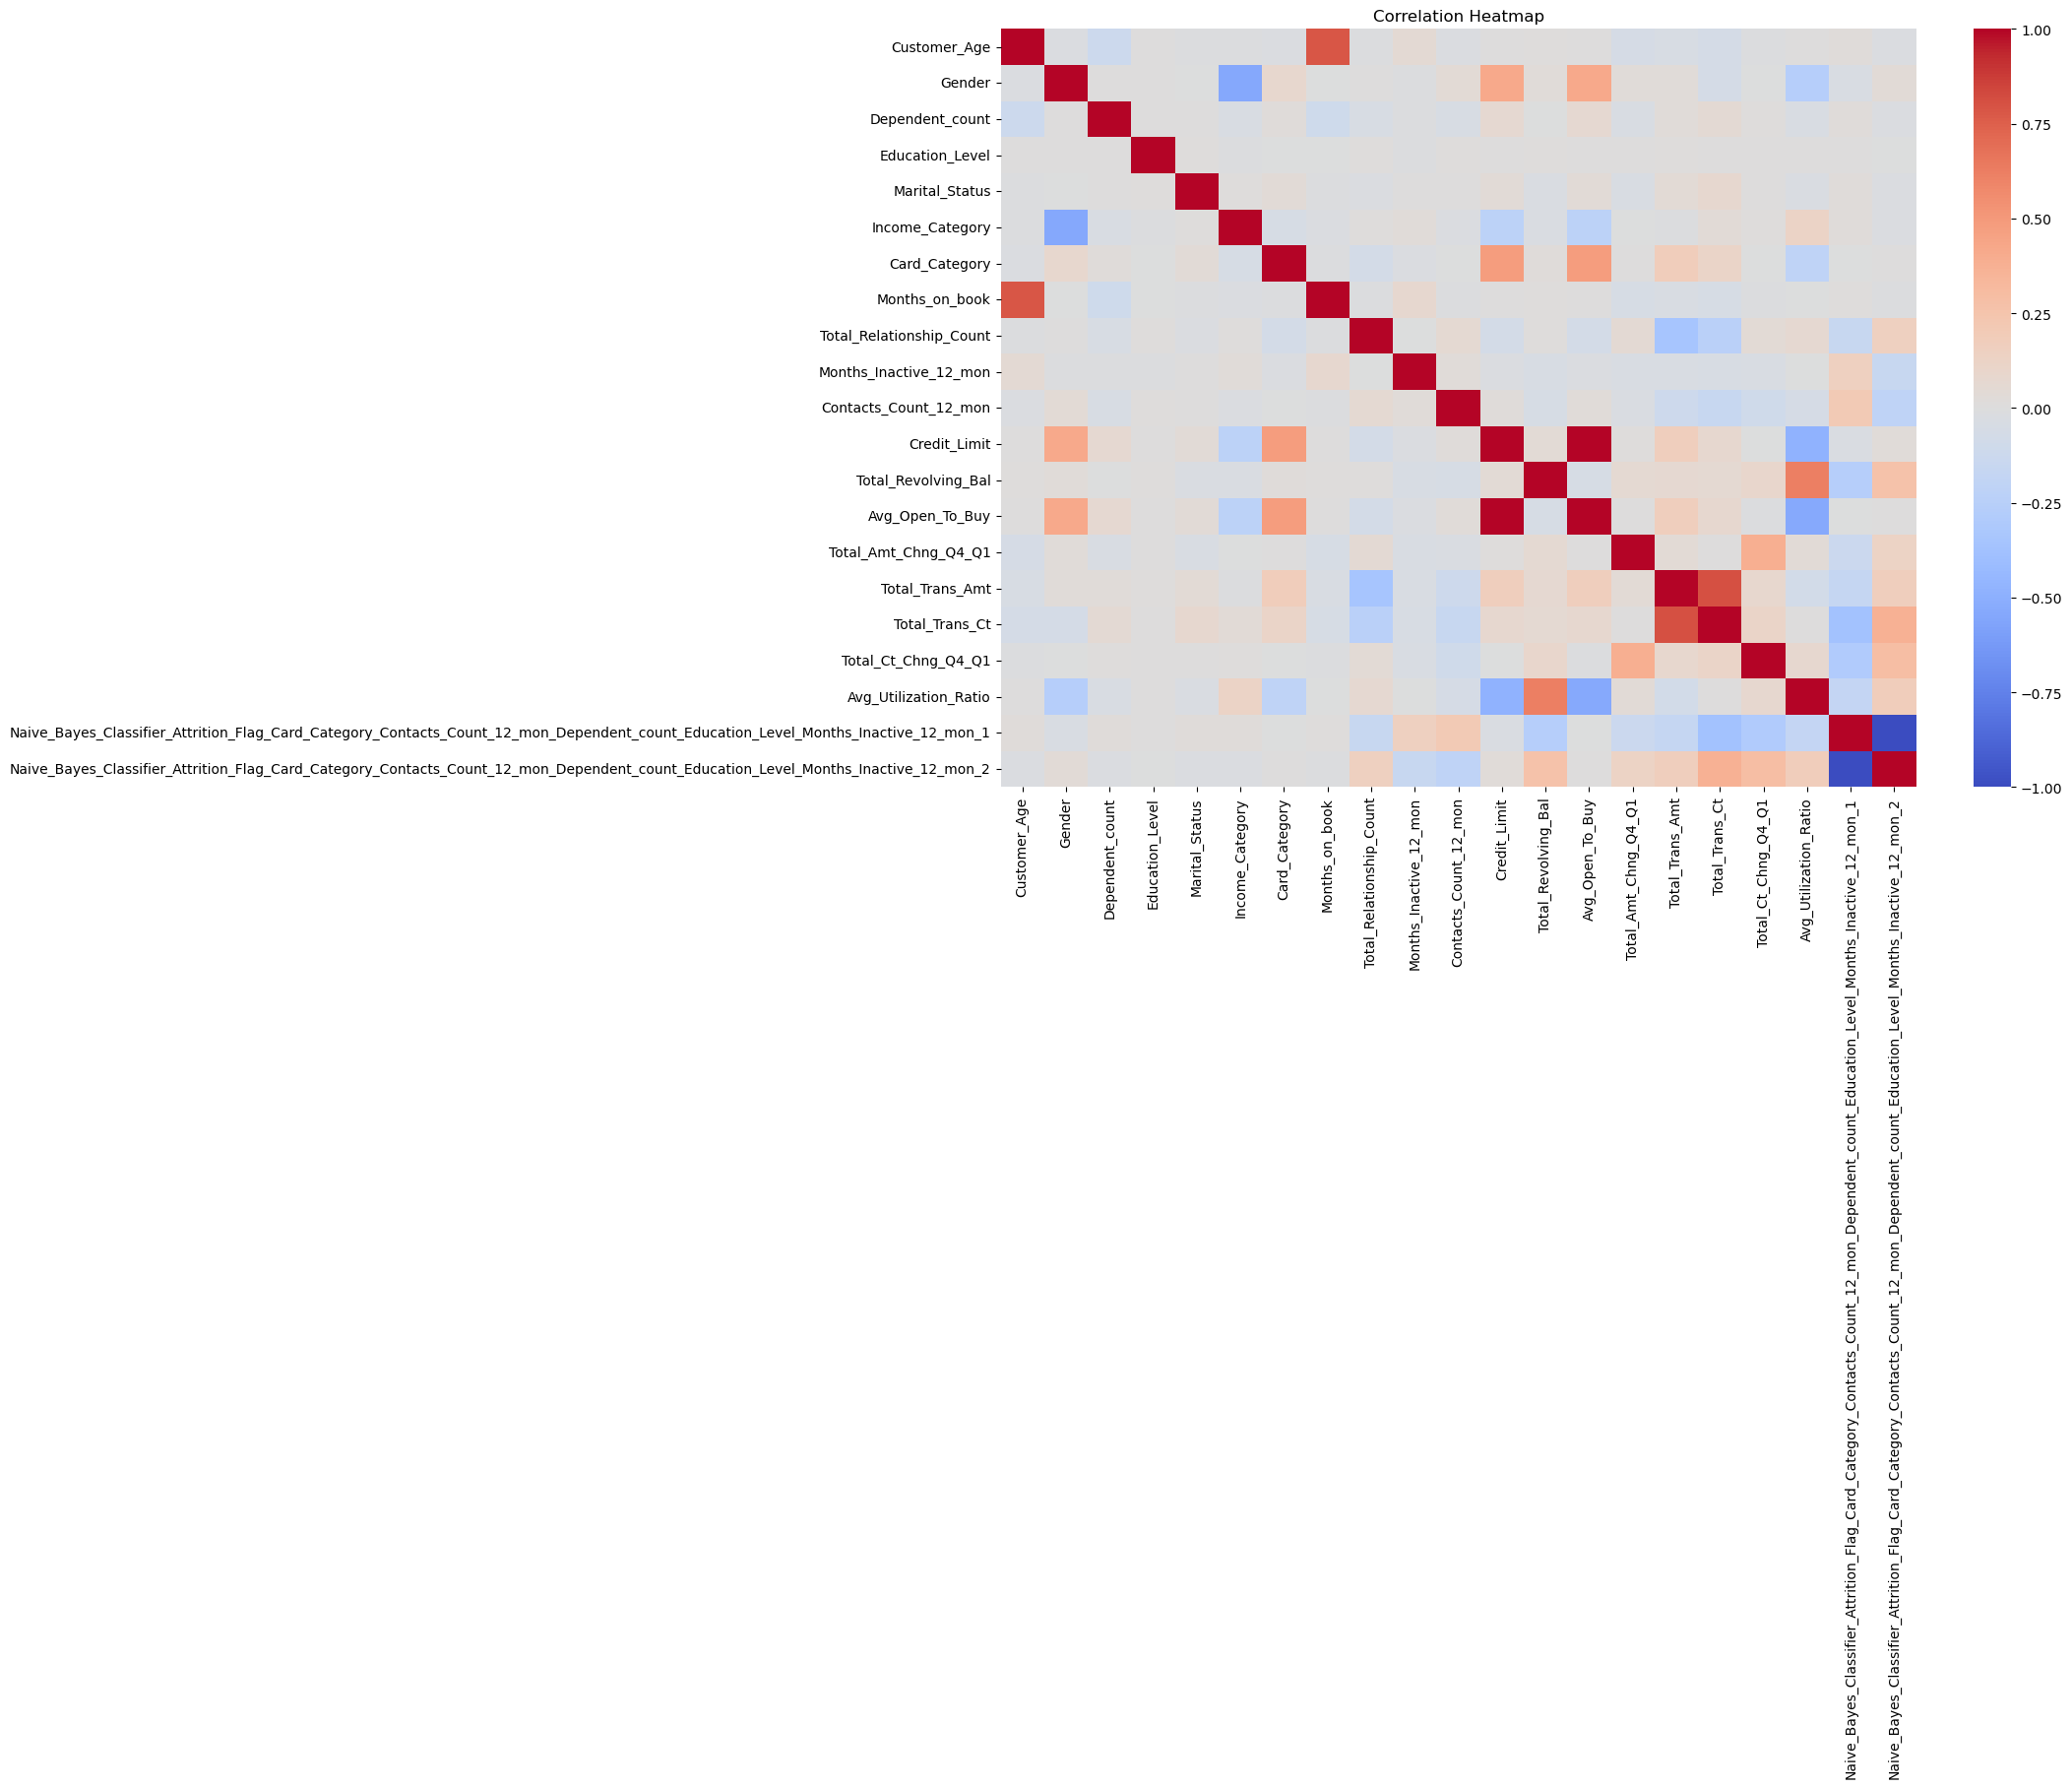

In [12]:
plt.figure(figsize=(15,10))

sns.heatmap(
    df_cluster.corr(),
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

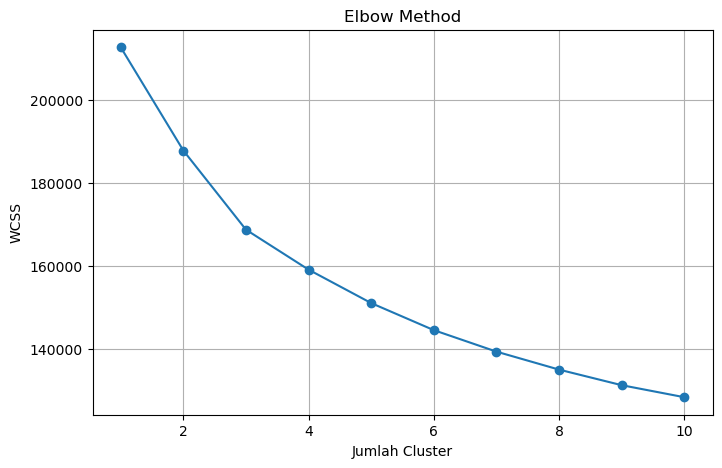

In [13]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title('Elbow Method')
plt.xlabel('Jumlah Cluster')
plt.ylabel('WCSS')
plt.grid(True)

plt.show()

In [15]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster = kmeans.fit_predict(X_scaled)

df['Cluster'] = cluster

In [16]:
print(df['Cluster'].value_counts())

Cluster
2    6752
1    1834
0    1541
Name: count, dtype: int64


In [17]:
print(df['Cluster'].value_counts())

Cluster
2    6752
1    1834
0    1541
Name: count, dtype: int64


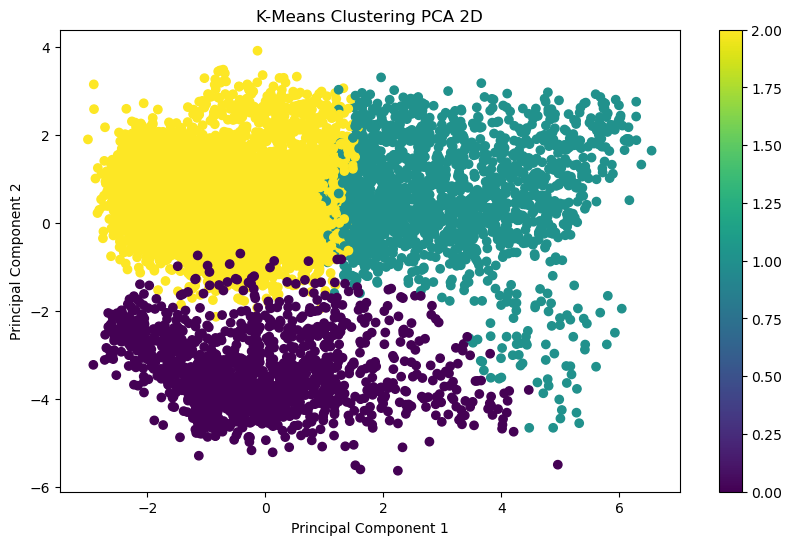

In [18]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=cluster,
    cmap='viridis'
)

plt.title('K-Means Clustering PCA 2D')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.colorbar(scatter)

plt.show()

In [19]:
print("Centroid Cluster")

print(kmeans.cluster_centers_)

Centroid Cluster
[[ 0.04295979 -0.13739895  0.03222595  0.00961347  0.03595552  0.07318414
  -0.15366021  0.03805493 -0.33365817  0.35398711  0.47363113 -0.20774223
  -0.61062671 -0.15295543 -0.327939   -0.43288829 -0.88357032 -0.69486987
  -0.37987412  2.2857577  -2.28575772]
 [-0.02243291  0.75190965  0.12638671  0.01928276  0.08580288 -0.45133241
   1.0654974  -0.01554669 -0.17759926 -0.08023169 -0.07002073  1.72752996
   0.0642909   1.72140352  0.04726017  0.54740284  0.3951338   0.0635487
  -0.79464435 -0.30989566  0.30989577]
 [-0.00371135 -0.17287774 -0.04168445 -0.00743171 -0.03151214  0.10588965
  -0.25434417 -0.00446238  0.12439045 -0.05899722 -0.08907695 -0.42182452
   0.12189962 -0.43266436  0.06200812 -0.0498898   0.09432857  0.14132792
   0.30254203 -0.43750059  0.43750056]]


In [20]:
df.to_csv(
    'hasil_clustering_bankchurners.csv',
    index=False
)

print("File berhasil disimpan")

File berhasil disimpan


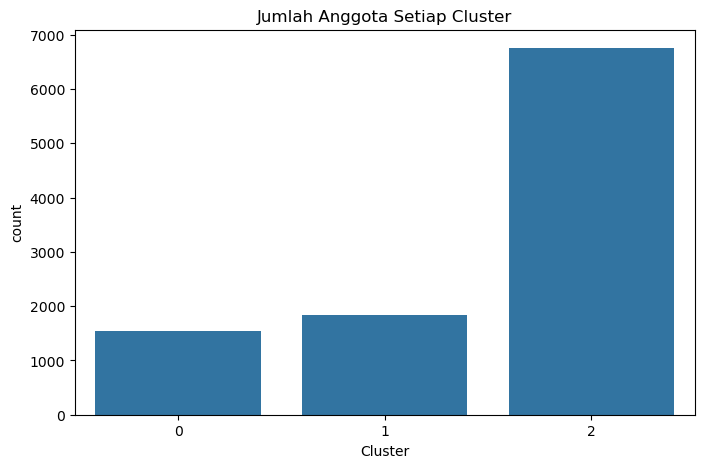

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Cluster',
    data=df
)

plt.title('Jumlah Anggota Setiap Cluster')

plt.show()

In [22]:
# Menambahkan hasil cluster ke dataset asli
df['Cluster'] = cluster

# Menyimpan hasil clustering
df.to_csv('Hasil_Clustering_BankChurners.csv', index=False)

print("Deployment berhasil!")
print("File tersimpan sebagai Hasil_Clustering_BankChurners.csv")

Deployment berhasil!
File tersimpan sebagai Hasil_Clustering_BankChurners.csv


In [23]:
cluster_count = df['Cluster'].value_counts().sort_index()

print(cluster_count)

Cluster
0    1541
1    1834
2    6752
Name: count, dtype: int64


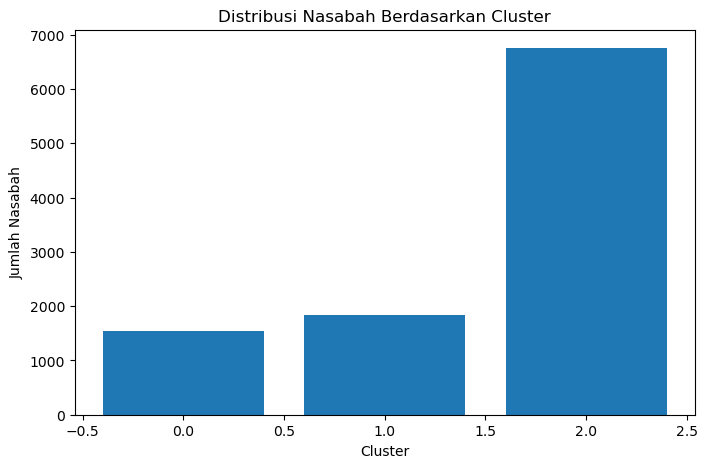

In [24]:
import matplotlib.pyplot as plt

cluster_count = df['Cluster'].value_counts().sort_index()

plt.figure(figsize=(8,5))

plt.bar(
    cluster_count.index,
    cluster_count.values
)

plt.title('Distribusi Nasabah Berdasarkan Cluster')
plt.xlabel('Cluster')
plt.ylabel('Jumlah Nasabah')

plt.show()

In [25]:
cluster_profile = df.groupby('Cluster').mean(numeric_only=True)

print(cluster_profile)

            CLIENTNUM  Customer_Age  Dependent_count  Months_on_book  \
Cluster                                                                
0        7.348987e+08     46.670344         2.388060       36.232317   
1        7.401206e+08     46.146129         2.510360       35.804253   
2        7.398980e+08     46.296209         2.292062       35.892773   

         Total_Relationship_Count  Months_Inactive_12_mon  \
Cluster                                                     
0                        3.293965                2.698897   
1                        3.536532                2.260087   
2                        4.005924                2.281546   

         Contacts_Count_12_mon  Credit_Limit  Total_Revolving_Bal  \
Cluster                                                             
0                     2.979234   6743.924205           665.185594   
1                     2.377863  24332.312432          1215.207743   
2                     2.356783   4798.274126          126

In [27]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, cluster)

In [28]:
print("="*50)
print("HASIL SEGMENTASI NASABAH BANK")
print("="*50)

print("\nJumlah Cluster:")
print(df['Cluster'].nunique())

print("\nJumlah Anggota Setiap Cluster:")
print(df['Cluster'].value_counts())

print("\nSilhouette Score:")
print(round(score,4))

print("\nKarakteristik Cluster:")
print(df.groupby('Cluster').mean(numeric_only=True))

HASIL SEGMENTASI NASABAH BANK

Jumlah Cluster:
3

Jumlah Anggota Setiap Cluster:
Cluster
2    6752
1    1834
0    1541
Name: count, dtype: int64

Silhouette Score:
0.1796

Karakteristik Cluster:
            CLIENTNUM  Customer_Age  Dependent_count  Months_on_book  \
Cluster                                                                
0        7.348987e+08     46.670344         2.388060       36.232317   
1        7.401206e+08     46.146129         2.510360       35.804253   
2        7.398980e+08     46.296209         2.292062       35.892773   

         Total_Relationship_Count  Months_Inactive_12_mon  \
Cluster                                                     
0                        3.293965                2.698897   
1                        3.536532                2.260087   
2                        4.005924                2.281546   

         Contacts_Count_12_mon  Credit_Limit  Total_Revolving_Bal  \
Cluster                                                             


In [29]:
print(df['Cluster'].value_counts())

Cluster
2    6752
1    1834
0    1541
Name: count, dtype: int64


In [31]:
print(round(score,4))

0.1796


In [32]:
cluster_summary = df.groupby('Cluster').mean(numeric_only=True)
print(cluster_summary)

            CLIENTNUM  Customer_Age  Dependent_count  Months_on_book  \
Cluster                                                                
0        7.348987e+08     46.670344         2.388060       36.232317   
1        7.401206e+08     46.146129         2.510360       35.804253   
2        7.398980e+08     46.296209         2.292062       35.892773   

         Total_Relationship_Count  Months_Inactive_12_mon  \
Cluster                                                     
0                        3.293965                2.698897   
1                        3.536532                2.260087   
2                        4.005924                2.281546   

         Contacts_Count_12_mon  Credit_Limit  Total_Revolving_Bal  \
Cluster                                                             
0                     2.979234   6743.924205           665.185594   
1                     2.377863  24332.312432          1215.207743   
2                     2.356783   4798.274126          126

In [33]:
df.to_csv("Hasil_Clustering_BankChurners.csv", index=False)